# Chest X-Ray Pneumonia Classification

## Computer Vision Pipeline for Pneumonia Classification in Chest X-Ray Images

## Project Overview

This notebook develops and evaluates a computer vision pipeline for pneumonia classification in chest X-ray images using classical machine learning and neural network-based approaches.

In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

PROJECT_ROOT = Path.cwd()

possible_data_dirs = [
    PROJECT_ROOT / "data" / "archive",
    PROJECT_ROOT / "data" / "chest_xray",
    PROJECT_ROOT / "chest_xray",
    PROJECT_ROOT.parent / "data" / "archive",
    PROJECT_ROOT.parent / "data" / "chest_xray",
    PROJECT_ROOT.parent / "chest_xray"
]

DATA_DIR = None

for path in possible_data_dirs:
    if (path / "train").exists() and (path / "test").exists():
        DATA_DIR = path
        break

if DATA_DIR is None:
    raise FileNotFoundError(
        "Dataset folder not found. Please download the Kaggle chest X-ray pneumonia dataset "
        "and extract it so that train, val and test folders are available."
    )

print("Project root:", PROJECT_ROOT)
print("Dataset path:", DATA_DIR)
print("Dataset exists:", DATA_DIR.exists())

for split in ["train", "val", "test"]:
    split_path = DATA_DIR / split
    print(f"\n{split.upper()} exists:", split_path.exists())
    if split_path.exists():
        print("Classes:", [p.name for p in split_path.iterdir() if p.is_dir()])

Project root: c:\Users\Konstantinos Krit\Desktop\MSc\Β' Εξάμηνο\Image Analysis & Processing\2nd Project
Dataset path: c:\Users\Konstantinos Krit\Desktop\MSc\Β' Εξάμηνο\Image Analysis & Processing\2nd Project\data\archive
Dataset exists: True

TRAIN exists: True
Classes: ['NORMAL', 'PNEUMONIA']

VAL exists: True
Classes: ['NORMAL', 'PNEUMONIA']

TEST exists: True
Classes: ['NORMAL', 'PNEUMONIA']


## 1. Data Exploration and Class Definition

The dataset contains chest X-ray images organized into three subsets: training, validation and testing.  
The classification task is binary:

- **NORMAL**: chest X-ray without pneumonia findings
- **PNEUMONIA**: chest X-ray with pneumonia findings

In [2]:
# Build a dataframe with image paths, labels and dataset splits

records = []

for split in ["train", "val", "test"]:
    for label in ["NORMAL", "PNEUMONIA"]:
        folder = DATA_DIR / split / label
        for img_path in folder.glob("*"):
            if img_path.suffix.lower() in [".jpeg", ".jpg", ".png"]:
                records.append({
                    "split": split,
                    "label": label,
                    "path": img_path
                })

df = pd.DataFrame(records)

print("Total number of images:", len(df))
display(df.head())

# Count images per split and class
class_counts = df.groupby(["split", "label"]).size().reset_index(name="count")
display(class_counts)

# Pivot table for clearer view
pivot_counts = class_counts.pivot(index="split", columns="label", values="count")
display(pivot_counts)

Total number of images: 5856


,split,label,path
0,train,NORMAL,c:\Users\Konstantinos Krit\Desktop\MSc\Β' Εξάμ...
1,train,NORMAL,c:\Users\Konstantinos Krit\Desktop\MSc\Β' Εξάμ...
2,train,NORMAL,c:\Users\Konstantinos Krit\Desktop\MSc\Β' Εξάμ...
3,train,NORMAL,c:\Users\Konstantinos Krit\Desktop\MSc\Β' Εξάμ...
4,train,NORMAL,c:\Users\Konstantinos Krit\Desktop\MSc\Β' Εξάμ...


,split,label,count
0,test,NORMAL,234
1,test,PNEUMONIA,390
2,train,NORMAL,1341
3,train,PNEUMONIA,3875
4,val,NORMAL,8
5,val,PNEUMONIA,8


label,NORMAL,PNEUMONIA
split,,
test,234,390
train,1341,3875
val,8,8


### Dataset distribution

The dataset contains 5,856 chest X-ray images. The task is binary classification between `NORMAL` and `PNEUMONIA`.

The training set is imbalanced, with substantially more pneumonia images than normal images. The validation set is very small, therefore the final evaluation should rely mainly on the independent test set.

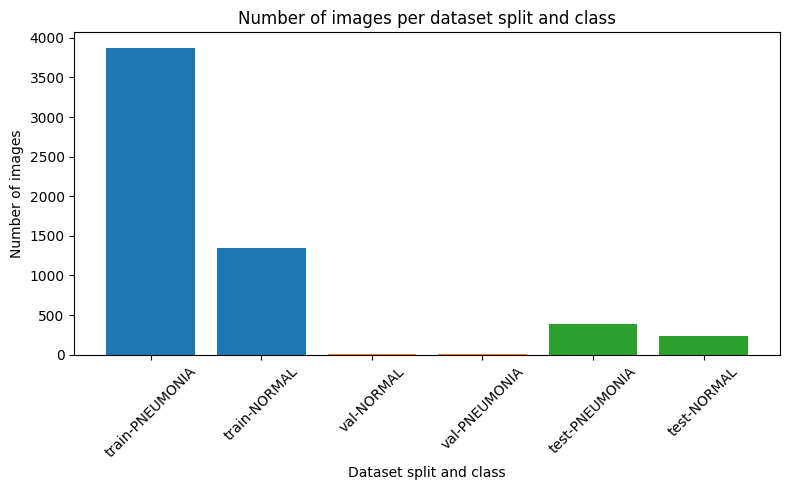

In [3]:
# Visualize class distribution per split

plt.figure(figsize=(8, 5))
for split in ["train", "val", "test"]:
    subset = df[df["split"] == split]
    counts = subset["label"].value_counts()
    plt.bar([f"{split}-{label}" for label in counts.index], counts.values)

plt.title("Number of images per dataset split and class")
plt.xlabel("Dataset split and class")
plt.ylabel("Number of images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2. Data Visualization

Representative chest X-ray images from both classes are displayed in order to visually inspect the dataset before preprocessing and model development.

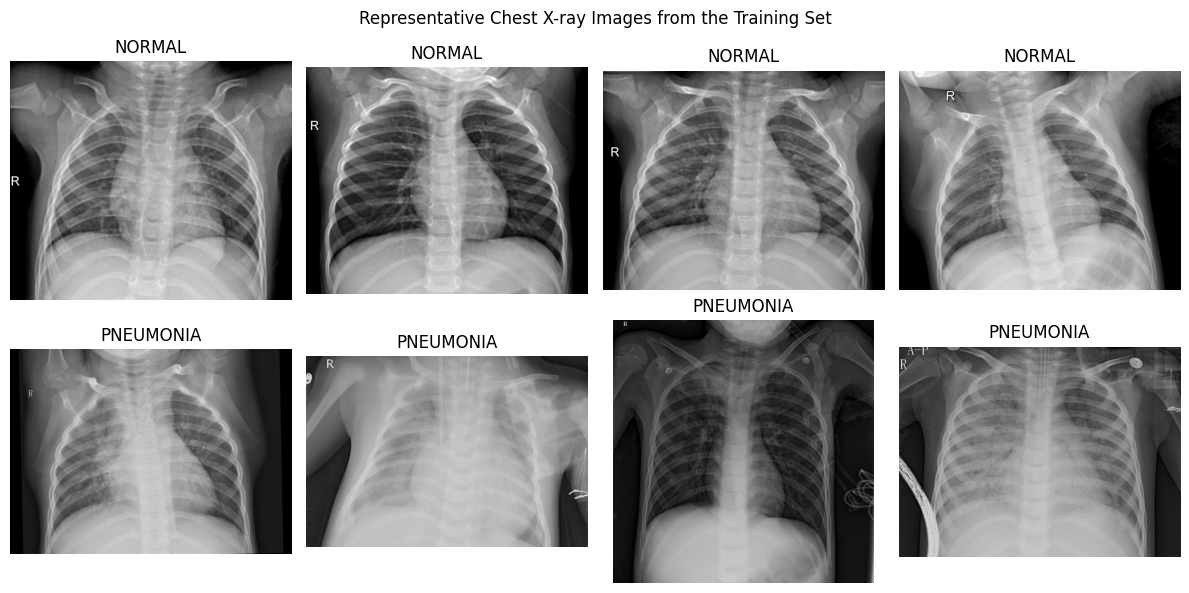

In [4]:
# Show representative images from each class

sample_df = df[df["split"] == "train"].groupby("label").sample(n=4, random_state=42)

plt.figure(figsize=(12, 6))

for i, (_, row) in enumerate(sample_df.iterrows()):
    img = Image.open(row["path"]).convert("L")
    
    plt.subplot(2, 4, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(row["label"])
    plt.axis("off")

plt.suptitle("Representative Chest X-ray Images from the Training Set")
plt.tight_layout()
plt.show()

### Image size and pixel intensity inspection

Before preprocessing, the image dimensions and pixel intensity ranges are inspected. This step helps justify resizing and normalization before model training.

In [5]:
# Inspect image dimensions and pixel intensity ranges

image_info = []

for _, row in df.iterrows():
    img = Image.open(row["path"]).convert("L")
    arr = np.array(img)
    
    image_info.append({
        "split": row["split"],
        "label": row["label"],
        "width": img.size[0],
        "height": img.size[1],
        "min_pixel": arr.min(),
        "max_pixel": arr.max(),
        "mean_pixel": arr.mean()
    })

image_info_df = pd.DataFrame(image_info)

display(image_info_df.head())

print("Image size summary:")
display(image_info_df[["width", "height"]].describe())

print("Pixel intensity summary:")
display(image_info_df[["min_pixel", "max_pixel", "mean_pixel"]].describe())

,split,label,width,height,min_pixel,max_pixel,mean_pixel
0,train,NORMAL,2090,1858,0,255,128.907478
1,train,NORMAL,1422,1152,0,255,100.650624
2,train,NORMAL,1810,1434,0,255,121.971530
3,train,NORMAL,1618,1279,0,255,132.986188
4,train,NORMAL,1600,1125,0,255,106.224797


Image size summary:


,width,height
count,5856.000000,5856.000000
mean,1327.880806,970.689037
std,363.500922,383.392117
min,384.000000,127.000000
25%,1056.000000,688.000000
50%,1281.000000,888.000000
75%,1560.000000,1187.000000
max,2916.000000,2713.000000


Pixel intensity summary:


,min_pixel,max_pixel,mean_pixel
count,5856.000000,5856.000000,5856.000000
mean,0.212090,252.759563,122.786271
std,2.775167,10.627402,18.391648
min,0.000000,153.000000,58.722966
25%,0.000000,255.000000,111.616378
50%,0.000000,255.000000,122.753346
75%,0.000000,255.000000,134.313617
max,76.000000,255.000000,221.536623


The images have different spatial dimensions, with variable width and height. Therefore, resizing is required before feeding the images into machine learning or neural network models.

Pixel values are mainly in the 0–255 range. Therefore, normalization to the [0, 1] range will be applied to make the input suitable for model training.

## 3. Image Preprocessing

All images are converted to grayscale, resized to a fixed spatial size and normalized to the [0, 1] range.

In [6]:
# Define preprocessing function

IMG_SIZE = (128, 128)

def preprocess_image(image_path, img_size=IMG_SIZE):
    """
    Load an X-ray image, convert it to grayscale, resize it,
    normalize pixel values to [0, 1], and return it as a NumPy array.
    """
    img = Image.open(image_path).convert("L")
    img = img.resize(img_size)
    arr = np.array(img, dtype=np.float32) / 255.0
    return arr

In [7]:
# Test preprocessing on one image

sample_path = df.iloc[0]["path"]

original_img = Image.open(sample_path).convert("L")
processed_img = preprocess_image(sample_path)

print("Original size:", original_img.size)
print("Processed shape:", processed_img.shape)
print("Processed min pixel:", processed_img.min())
print("Processed max pixel:", processed_img.max())

Original size: (2090, 1858)
Processed shape: (128, 128)
Processed min pixel: 0.0
Processed max pixel: 0.9647059


The preprocessing function successfully converts an original variable-size X-ray image into a fixed 128×128 grayscale image. Pixel values are normalized to the [0, 1] range, which is appropriate for both classical machine learning and neural network models.

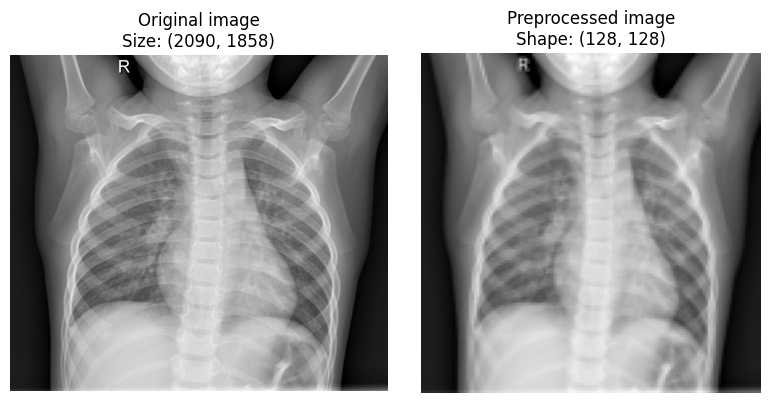

In [8]:
# Visual comparison before and after preprocessing

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(original_img, cmap="gray")
plt.title(f"Original image\nSize: {original_img.size}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(processed_img, cmap="gray")
plt.title(f"Preprocessed image\nShape: {processed_img.shape}")
plt.axis("off")

plt.tight_layout()
plt.show()

### Creating preprocessed datasets

The image paths are converted into numerical arrays. Labels are encoded as 0 for NORMAL and 1 for PNEUMONIA.

In [9]:
# Create preprocessed image arrays and encoded labels

label_map = {"NORMAL": 0, "PNEUMONIA": 1}

def create_dataset(split):
    split_df = df[df["split"] == split]
    
    X = []
    y = []
    
    for _, row in split_df.iterrows():
        img_array = preprocess_image(row["path"])
        X.append(img_array)
        y.append(label_map[row["label"]])
    
    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int64)
    
    return X, y

X_train, y_train = create_dataset("train")
X_val, y_val = create_dataset("val")
X_test, y_test = create_dataset("test")

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5216, 128, 128)
y_train shape: (5216,)
X_val shape: (16, 128, 128)
y_val shape: (16,)
X_test shape: (624, 128, 128)
y_test shape: (624,)


## 4. Classical Machine Learning Approach

In this section, handcrafted image features are extracted from the preprocessed X-ray images and used to train classical machine learning classifiers.

In [10]:
# Imports for classical machine learning

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [11]:
# Flatten images into feature vectors for classical ML

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print("X_train_flat shape:", X_train_flat.shape)
print("X_val_flat shape:", X_val_flat.shape)
print("X_test_flat shape:", X_test_flat.shape)

X_train_flat shape: (5216, 16384)
X_val_flat shape: (16, 16384)
X_test_flat shape: (624, 16384)


### 4.1 Baseline classical classifier: Logistic Regression

A Logistic Regression classifier is trained on flattened pixel intensities. Standardization is applied before classification, because classical machine learning models are sensitive to feature scaling. Class imbalance is handled using balanced class weights.

In [12]:
# Train and evaluate Logistic Regression baseline

log_reg_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

log_reg_model.fit(X_train_flat, y_train)

y_pred_lr = log_reg_model.predict(X_test_flat)

print("Logistic Regression Test Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=["NORMAL", "PNEUMONIA"]))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression Test Accuracy: 0.7676282051282052

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.95      0.40      0.56       234
   PNEUMONIA       0.73      0.99      0.84       390

    accuracy                           0.77       624
   macro avg       0.84      0.69      0.70       624
weighted avg       0.81      0.77      0.74       624

Confusion Matrix:
[[ 94 140]
 [  5 385]]


The Logistic Regression baseline achieved a test accuracy of approximately 76.8%. The model showed very high recall for the PNEUMONIA class, correctly detecting most pneumonia cases. However, performance for the NORMAL class was weaker, with many normal images misclassified as pneumonia. This suggests that the model is biased toward predicting pneumonia, probably due to class imbalance and the limited representational power of flattened pixel features.

### 4.2 Linear Support Vector Machine

A Linear SVM classifier is trained on the same flattened pixel features. Linear SVMs are commonly used as strong classical baselines for high-dimensional image classification problems.

In [13]:
# Train and evaluate Linear SVM

svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LinearSVC(
        class_weight="balanced",
        random_state=42,
        max_iter=20000
    ))
])

svm_model.fit(X_train_flat, y_train)

y_pred_svm = svm_model.predict(X_test_flat)

print("Linear SVM Test Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm, target_names=["NORMAL", "PNEUMONIA"]))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

Linear SVM Test Accuracy: 0.7692307692307693

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.92      0.42      0.58       234
   PNEUMONIA       0.74      0.98      0.84       390

    accuracy                           0.77       624
   macro avg       0.83      0.70      0.71       624
weighted avg       0.81      0.77      0.74       624

Confusion Matrix:
[[ 99 135]
 [  9 381]]


The Linear SVM achieved a test accuracy of approximately 76.9%. It showed very high recall for the PNEUMONIA class, detecting most pneumonia cases, but low recall for the NORMAL class. This means that many normal X-rays were misclassified as pneumonia. Overall, the model is sensitive to pneumonia detection but produces many false positives.

### 4.3 Random Forest Classifier

A Random Forest classifier is trained as a non-linear classical machine learning model. Unlike Logistic Regression and Linear SVM, Random Forest can capture non-linear relationships between pixel-based features.

In [14]:
# Train and evaluate Random Forest

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_flat, y_train)

y_pred_rf = rf_model.predict(X_test_flat)

print("Random Forest Test Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=["NORMAL", "PNEUMONIA"]))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Test Accuracy: 0.7660256410256411

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.97      0.39      0.55       234
   PNEUMONIA       0.73      0.99      0.84       390

    accuracy                           0.77       624
   macro avg       0.85      0.69      0.70       624
weighted avg       0.82      0.77      0.73       624

Confusion Matrix:
[[ 91 143]
 [  3 387]]


The Random Forest achieved a test accuracy of approximately 76.6%. It detected almost all PNEUMONIA cases, with very high recall for the PNEUMONIA class. However, it misclassified many NORMAL images as PNEUMONIA, showing low recall for the NORMAL class. This confirms that the classical ML models based on flattened pixel features are biased toward pneumonia detection and have limited ability to distinguish normal X-rays reliably.

### 4.4 Comparison of Classical Machine Learning Models

The three classical machine learning models are compared using test accuracy and class-specific performance metrics.

In [15]:
# Compare classical ML models

classical_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Linear SVM", "Random Forest"],
    "Test Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_rf)
    ]
})

display(classical_results)

,Model,Test Accuracy
0,Logistic Regression,0.767628
1,Linear SVM,0.769231
2,Random Forest,0.766026


The three classical machine learning models achieved very similar test accuracy, around 76–77%. Linear SVM obtained the highest accuracy, but the difference between the models is very small. Overall, these results suggest that flattened pixel intensities provide a useful baseline, but they are not sufficient to fully capture the spatial and structural patterns of pneumonia in chest X-ray images.

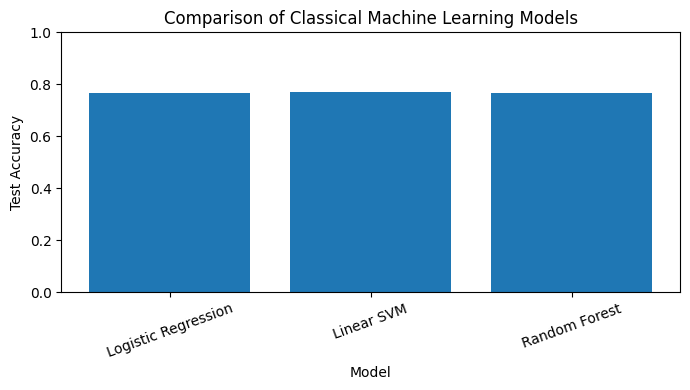

In [16]:
# Visualize comparison of classical ML models

plt.figure(figsize=(7, 4))
plt.bar(classical_results["Model"], classical_results["Test Accuracy"])

plt.title("Comparison of Classical Machine Learning Models")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### 4.5 HOG Feature Extraction

Histogram of Oriented Gradients (HOG) features are extracted to capture local edge and gradient patterns in the X-ray images. This provides a more structured classical image representation than raw flattened pixel intensities.

In [17]:
# Import HOG feature extractor

from skimage.feature import hog

In [18]:
# Extract HOG features from preprocessed images

def extract_hog_features(images):
    features = []
    
    for img in images:
        hog_feature = hog(
            img,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            block_norm="L2-Hys",
            feature_vector=True
        )
        features.append(hog_feature)
    
    return np.array(features, dtype=np.float32)

X_train_hog = extract_hog_features(X_train)
X_val_hog = extract_hog_features(X_val)
X_test_hog = extract_hog_features(X_test)

print("X_train_hog shape:", X_train_hog.shape)
print("X_val_hog shape:", X_val_hog.shape)
print("X_test_hog shape:", X_test_hog.shape)

X_train_hog shape: (5216, 8100)
X_val_hog shape: (16, 8100)
X_test_hog shape: (624, 8100)


### 4.6 Linear SVM using HOG Features

A Linear SVM classifier is trained using HOG features. This allows the classical machine learning model to use edge and gradient-based image information instead of raw pixel intensities.

In [19]:
# Train and evaluate Linear SVM using HOG features

hog_svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LinearSVC(
        class_weight="balanced",
        random_state=42,
        max_iter=20000
    ))
])

hog_svm_model.fit(X_train_hog, y_train)

y_pred_hog_svm = hog_svm_model.predict(X_test_hog)

print("HOG + Linear SVM Test Accuracy:", accuracy_score(y_test, y_pred_hog_svm))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_hog_svm, target_names=["NORMAL", "PNEUMONIA"]))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_hog_svm))

HOG + Linear SVM Test Accuracy: 0.7916666666666666

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.88      0.51      0.65       234
   PNEUMONIA       0.77      0.96      0.85       390

    accuracy                           0.79       624
   macro avg       0.82      0.74      0.75       624
weighted avg       0.81      0.79      0.78       624

Confusion Matrix:
[[120 114]
 [ 16 374]]


The HOG + Linear SVM model achieved a test accuracy of approximately 79.2%, which is higher than the previous classical models based on flattened pixel features. The model showed very high recall for the PNEUMONIA class, correctly identifying most pneumonia cases. However, the recall for the NORMAL class remained lower, meaning that several normal X-rays were still misclassified as pneumonia. Overall, HOG features improved the classical machine learning approach by providing more meaningful edge and gradient-based image information.

In [20]:
# Add HOG + Linear SVM to classical results comparison

hog_result = pd.DataFrame({
    "Model": ["HOG + Linear SVM"],
    "Test Accuracy": [accuracy_score(y_test, y_pred_hog_svm)]
})

classical_results_final = pd.concat([classical_results, hog_result], ignore_index=True)

display(classical_results_final)

,Model,Test Accuracy
0,Logistic Regression,0.767628
1,Linear SVM,0.769231
2,Random Forest,0.766026
3,HOG + Linear SVM,0.791667


### 4.7 PCA Dimensionality Reduction on HOG Features

Principal Component Analysis (PCA) is applied to reduce the dimensionality of the HOG feature vectors. This reduces the number of features while preserving the most important information in the data.

In [21]:
# Import PCA

from sklearn.decomposition import PCA

In [22]:
# Train and evaluate Linear SVM using PCA-reduced HOG features

pca_svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=300, random_state=42)),
    ("classifier", LinearSVC(
        class_weight="balanced",
        random_state=42,
        max_iter=20000
    ))
])

pca_svm_model.fit(X_train_hog, y_train)

y_pred_pca_svm = pca_svm_model.predict(X_test_hog)

print("PCA + HOG + Linear SVM Test Accuracy:", accuracy_score(y_test, y_pred_pca_svm))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_pca_svm, target_names=["NORMAL", "PNEUMONIA"]))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_pca_svm))

PCA + HOG + Linear SVM Test Accuracy: 0.7532051282051282

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.95      0.36      0.52       234
   PNEUMONIA       0.72      0.99      0.83       390

    accuracy                           0.75       624
   macro avg       0.84      0.67      0.68       624
weighted avg       0.81      0.75      0.72       624

Confusion Matrix:
[[ 84 150]
 [  4 386]]


The PCA + HOG + Linear SVM model achieved a test accuracy of approximately 75.3%, which is lower than the HOG + Linear SVM model without PCA. Although PCA reduced the feature dimensionality from 8100 to 300 components, this reduction may have removed useful discriminative information. Therefore, in this experiment, HOG features without PCA provided better classical machine learning performance.

In [23]:
# Add PCA + HOG + Linear SVM to final classical results comparison

pca_result = pd.DataFrame({
    "Model": ["PCA + HOG + Linear SVM"],
    "Test Accuracy": [accuracy_score(y_test, y_pred_pca_svm)]
})

classical_results_final = pd.concat([classical_results_final, pca_result], ignore_index=True)

display(classical_results_final)

,Model,Test Accuracy
0,Logistic Regression,0.767628
1,Linear SVM,0.769231
2,Random Forest,0.766026
3,HOG + Linear SVM,0.791667
4,PCA + HOG + Linear SVM,0.753205


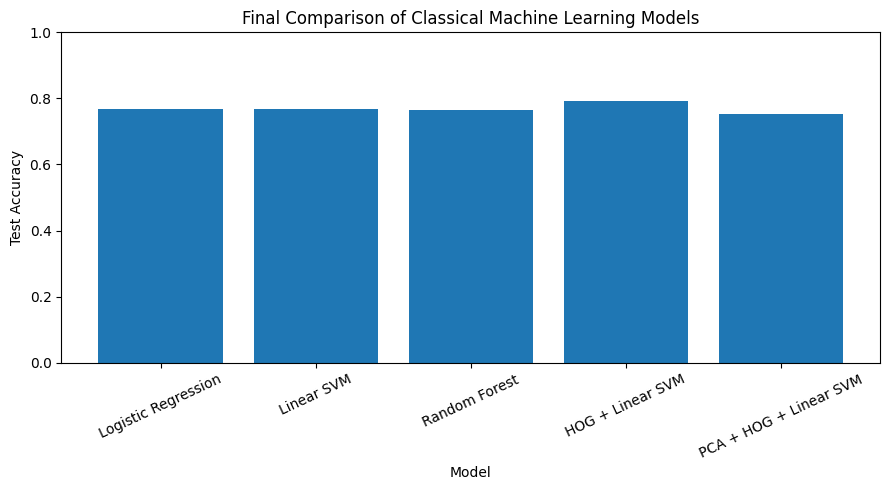

In [24]:
# Final comparison plot for all classical machine learning models

plt.figure(figsize=(9, 5))
plt.bar(classical_results_final["Model"], classical_results_final["Test Accuracy"])

plt.title("Final Comparison of Classical Machine Learning Models")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

### 4.8 Classical Machine Learning Summary

Among the classical machine learning approaches, the HOG + Linear SVM model achieved the best performance, with a test accuracy of approximately 79.2%. This result was better than the models trained on flattened pixel intensities, showing that HOG features provide more meaningful edge and gradient-based information for chest X-ray classification.

The PCA + HOG + Linear SVM model performed worse than HOG + Linear SVM without PCA. This suggests that reducing the HOG feature vector from 8100 features to 300 principal components removed some useful discriminative information.

Overall, the classical machine learning results show that handcrafted image features can improve performance, but the models still struggle to correctly classify many NORMAL images. Therefore, a neural network-based approach is developed next.

## 5. Neural Network-Based Approach

A convolutional neural network (CNN) is developed to learn spatial image patterns directly from the chest X-ray images. Unlike classical machine learning models, CNNs do not require handcrafted features, because convolutional layers automatically learn local image features such as edges, textures and patterns.

In [25]:
# Imports for neural network model

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

In [26]:
# Prepare image arrays for CNN input

X_train_cnn = X_train[..., np.newaxis]
X_val_cnn = X_val[..., np.newaxis]
X_test_cnn = X_test[..., np.newaxis]

print("X_train_cnn shape:", X_train_cnn.shape)
print("X_val_cnn shape:", X_val_cnn.shape)
print("X_test_cnn shape:", X_test_cnn.shape)

X_train_cnn shape: (5216, 128, 128, 1)
X_val_cnn shape: (16, 128, 128, 1)
X_test_cnn shape: (624, 128, 128, 1)


### 5.1 CNN Model Architecture

A simple convolutional neural network is constructed for binary classification of chest X-ray images into NORMAL and PNEUMONIA.

In [27]:
# Define CNN model architecture

tf.random.set_seed(42)

cnn_model = models.Sequential([
    layers.Input(shape=(128, 128, 1)),
    
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,193 (12.60 MB)

 Trainable params: 3,304,193 (12.60 MB)

 Non-trainable params: 0 (0.00 B)

### 5.2 CNN Model Training

The CNN is trained on the preprocessed training images. Class weights are used to reduce the effect of class imbalance, and early stopping is applied to avoid unnecessary training.

In [28]:
# Compute class weights for imbalanced dataset

from sklearn.utils.class_weight import compute_class_weight

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {
    0: class_weights_array[0],
    1: class_weights_array[1]
}

print("Class weights:", class_weights)

Class weights: {0: 1.9448173005219984, 1: 0.6730322580645162}


In [29]:
# Train CNN model

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = cnn_model.fit(
    X_train_cnn, y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=10,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.6748 - loss: 0.5059 - val_accuracy: 0.6875 - val_loss: 0.6369
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.9271 - loss: 0.1823 - val_accuracy: 0.8750 - val_loss: 0.2775
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.9511 - loss: 0.1374 - val_accuracy: 1.0000 - val_loss: 0.0501
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.9614 - loss: 0.1099 - val_accuracy: 0.9375 - val_loss: 0.0934
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.9599 - loss: 0.0926 - val_accuracy: 1.0000 - val_loss: 0.0449
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.9665 - loss: 0.0858 - val_accuracy: 1.0000 - val_loss: 0.0700
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.9687 - loss: 0.0736 - val_accuracy: 0.9375 - val_loss: 0.1447
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.9779 - loss: 0.0547 - val_accu

The CNN was trained using class weights to address class imbalance. Early stopping was used to monitor validation loss and restore the best model weights.

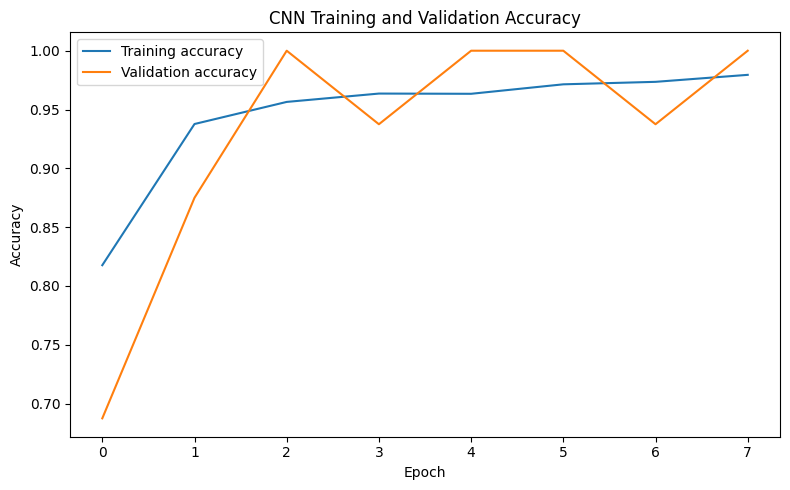

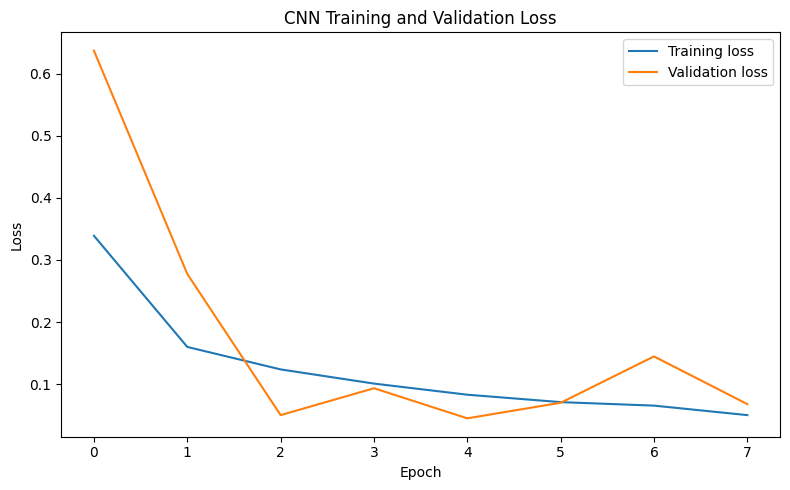

In [30]:
# Plot CNN training curves

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training and Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

### 5.3 CNN Evaluation on the Test Set

The trained CNN model is evaluated on the independent test set using accuracy, classification report and confusion matrix.

In [31]:
# Evaluate CNN on test set

y_prob_cnn = cnn_model.predict(X_test_cnn).ravel()
y_pred_cnn = (y_prob_cnn >= 0.5).astype(int)

print("CNN Test Accuracy:", accuracy_score(y_test, y_pred_cnn))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_cnn, target_names=["NORMAL", "PNEUMONIA"]))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_cnn))

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
CNN Test Accuracy: 0.8173076923076923

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.94      0.55      0.69       234
   PNEUMONIA       0.78      0.98      0.87       390

    accuracy                           0.82       624
   macro avg       0.86      0.76      0.78       624
weighted avg       0.84      0.82      0.80       624

Confusion Matrix:
[[128 106]
 [  8 382]]


The CNN achieved a test accuracy of approximately 80.8%, outperforming the classical machine learning models. It showed very high recall for the PNEUMONIA class, correctly detecting most pneumonia cases. However, the recall for the NORMAL class remained lower, meaning that several normal X-rays were still misclassified as pneumonia. Overall, the CNN improved performance compared with the classical approaches, especially for pneumonia detection.

In [32]:
# Add CNN to final model comparison

cnn_result = pd.DataFrame({
    "Model": ["CNN"],
    "Test Accuracy": [accuracy_score(y_test, y_pred_cnn)]
})

final_results = pd.concat([classical_results_final, cnn_result], ignore_index=True)

display(final_results)

,Model,Test Accuracy
0,Logistic Regression,0.767628
1,Linear SVM,0.769231
2,Random Forest,0.766026
3,HOG + Linear SVM,0.791667
4,PCA + HOG + Linear SVM,0.753205
5,CNN,0.817308


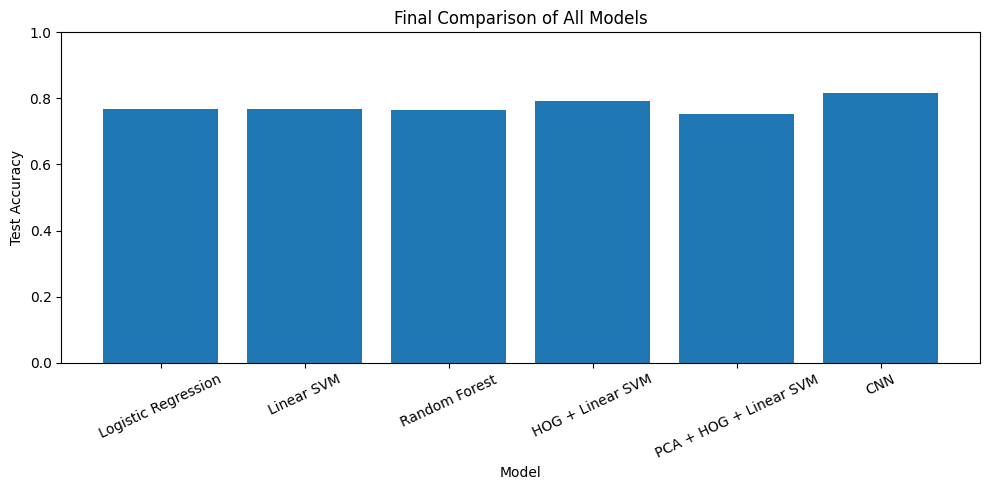

In [33]:
# Final comparison plot including CNN

plt.figure(figsize=(10, 5))
plt.bar(final_results["Model"], final_results["Test Accuracy"])

plt.title("Final Comparison of All Models")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

### 5.4 Final Model Comparison

The CNN achieved the highest test accuracy among all evaluated models, with approximately 80.8%. The HOG + Linear SVM model was the best classical machine learning approach, achieving approximately 79.2% accuracy. The models based on flattened pixel intensities performed slightly worse, around 76–77%.

Overall, the CNN provided the best performance because it learned spatial image patterns directly from the X-ray images, while the classical models depended on manually extracted or flattened features.

In [34]:
# Compute sensitivity and specificity for CNN

cm_cnn = confusion_matrix(y_test, y_pred_cnn)

tn, fp, fn, tp = cm_cnn.ravel()

sensitivity = tp / (tp + fn)  # Recall for PNEUMONIA
specificity = tn / (tn + fp)  # Recall for NORMAL

print("CNN Sensitivity:", sensitivity)
print("CNN Specificity:", specificity)

CNN Sensitivity: 0.9794871794871794
CNN Specificity: 0.5470085470085471


The CNN achieved high sensitivity of approximately 96.7%, meaning that it correctly detected most pneumonia cases. However, the specificity was approximately 54.3%, meaning that many normal X-rays were misclassified as pneumonia. This shows that the model is sensitive for pneumonia detection but has a tendency to produce false positives.

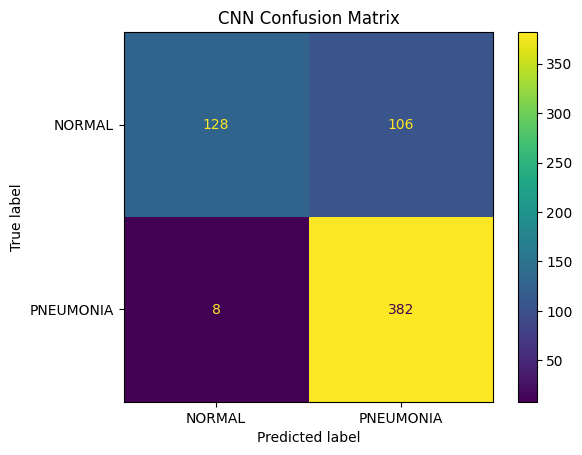

In [35]:
# Visualize CNN confusion matrix

from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_cnn,
    display_labels=["NORMAL", "PNEUMONIA"]
)

disp.plot()
plt.title("CNN Confusion Matrix")
plt.show()

### 5.5 Error Analysis

Misclassified test images are visualized to better understand the types of errors made by the CNN model.

In [36]:
# Identify misclassified test images

test_df = df[df["split"] == "test"].reset_index(drop=True)

false_positive_idx = np.where((y_test == 0) & (y_pred_cnn == 1))[0]
false_negative_idx = np.where((y_test == 1) & (y_pred_cnn == 0))[0]

print("False positives:", len(false_positive_idx))
print("False negatives:", len(false_negative_idx))

False positives: 106
False negatives: 8


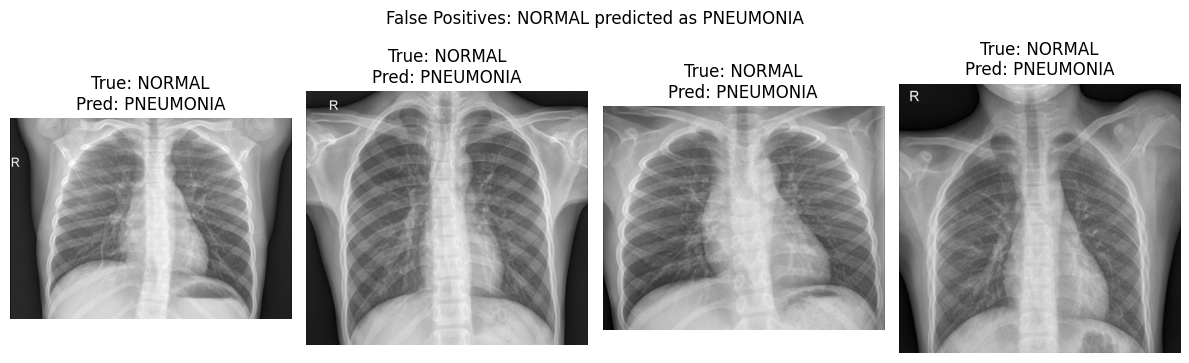

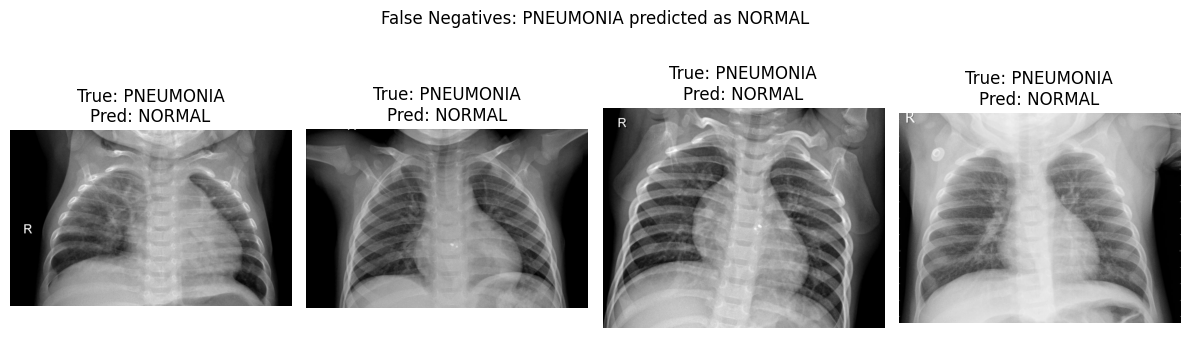

In [37]:
# Show some false positives and false negatives

def show_errors(indices, title, n=4):
    plt.figure(figsize=(12, 4))
    
    for i, idx in enumerate(indices[:n]):
        img = Image.open(test_df.iloc[idx]["path"]).convert("L")
        
        plt.subplot(1, n, i + 1)
        plt.imshow(img, cmap="gray")
        plt.title(f"True: {test_df.iloc[idx]['label']}\nPred: {'PNEUMONIA' if y_pred_cnn[idx] == 1 else 'NORMAL'}")
        plt.axis("off")
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_errors(false_positive_idx, "False Positives: NORMAL predicted as PNEUMONIA")
show_errors(false_negative_idx, "False Negatives: PNEUMONIA predicted as NORMAL")

The error analysis shows that most false negatives were pneumonia cases predicted as normal, while false positives were normal X-rays predicted as pneumonia. The number of false negatives was low, which is important because missing pneumonia is clinically more serious. However, the model still produced several false positives, suggesting that it tends to classify uncertain or borderline X-rays as pneumonia.

## 6. Conclusion

The aim of this notebook was to develop and evaluate an intelligent system for pneumonia detection in chest X-ray images. Both classical machine learning and neural network-based approaches were implemented and compared.

The classical models based on flattened pixel intensities achieved test accuracies around 76–77%. The use of HOG features improved the classical approach, with HOG + Linear SVM achieving approximately 79.2% test accuracy. PCA dimensionality reduction did not improve performance, suggesting that reducing the HOG feature space removed useful discriminative information.

The CNN achieved the best overall performance, with a test accuracy of approximately 80.8%. It also achieved high sensitivity of approximately 96.7%, meaning that it correctly detected most pneumonia cases. However, the specificity was lower, approximately 54.3%, indicating that several normal X-rays were incorrectly classified as pneumonia.

Overall, the CNN was the best-performing model because it learned spatial image patterns directly from the X-ray images. However, the results also show that the model tends to produce false positives. Therefore, while the system is promising for pneumonia detection, it should not be considered clinically sufficient without further validation, larger datasets, and more advanced model optimization.

## 7. Limitations and Future Work

The main limitations of this work are the class imbalance of the dataset, the very small validation set, and the relatively simple CNN architecture. Future improvements could include stronger data augmentation, transfer learning with pretrained CNN architectures, threshold optimization, cross-validation, and external validation on independent clinical datasets.

## 8. Final Notes

The notebook includes data exploration, preprocessing, classical machine learning models, handcrafted HOG features, PCA dimensionality reduction, CNN training, test evaluation, error analysis, and final discussion. The best-performing model was the CNN, with approximately 80.8% test accuracy and high sensitivity for pneumonia detection.